In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:


teachers = pd.read_csv("teacher_data.csv")
courses = pd.read_csv("Course_data1.csv")
transactions = pd.read_csv("transaction_data1.csv")

In [7]:
teachers.isnull()

,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False


In [8]:
courses.isnull()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False


In [10]:
transactions.isnull()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False


In [11]:
teachers.duplicated().sum()
courses.duplicated().sum()
transactions.duplicated().sum()

0

In [12]:
merged = transactions.merge(
    teachers,
    on='TeacherID'
)

merged = merged.merge(
    courses,
    on='CourseID'
)

merged.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,TT00001,U00003,CR00016,25/10/2025,0.0,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72
1,TT00002,U00003,CR00037,13/1/2025,0.0,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45
2,TT00003,U00003,CR00019,28/3/2025,0.0,Bank Transfer,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98
3,TT00004,U00004,CR00048,2/6/2025,0.0,Bank Transfer,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64
4,TT00005,U00004,CR00060,10/8/2025,0.0,PayPal,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14


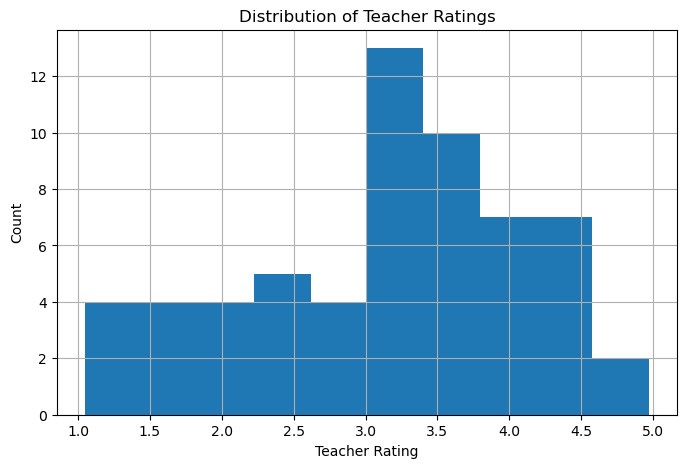

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
teachers['TeacherRating'].hist(bins=10)
plt.title('Distribution of Teacher Ratings')
plt.xlabel('Teacher Rating')
plt.ylabel('Count')
plt.show()



###Teacher ratings range from low to high performers, with most instructors clustered around the average rating level.

In [16]:
top_teachers = teachers.sort_values(
    by='TeacherRating',
    ascending=False
).head(10)

print(top_teachers[['TeacherName','Expertise','TeacherRating']])

        TeacherName                Expertise  TeacherRating
41   Yolanda Levine         Machine Learning           4.97
39  Kimberly Miller            Cybersecurity           4.58
36    Debra Escobar                  Finance           4.39
3      Kristi Scott         Machine Learning           4.39
6      Angela Beard         Machine Learning           4.36
52      Aaron Kirby                Marketing           4.29
53   Shelby Patrick  Artificial Intelligence           4.28
17      Kari Pierce       Project Management           4.28
23      Michael Kim        Digital Marketing           4.22
1          Jill Day        Digital Marketing           4.14


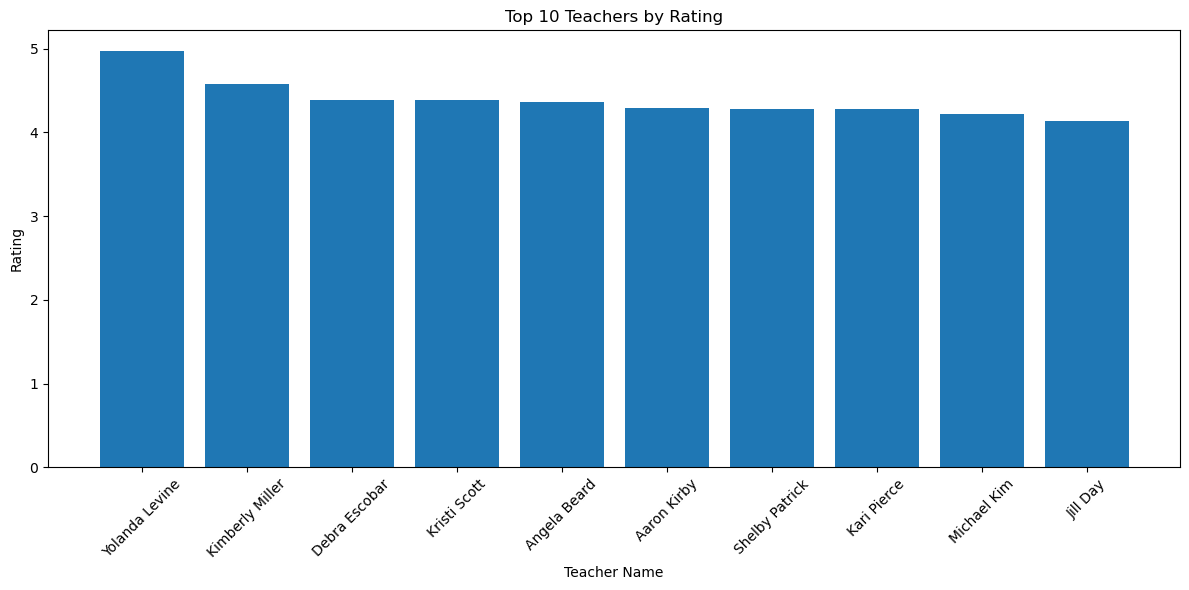

In [22]:
plt.figure(figsize=(12,6))
plt.bar(top_teachers['TeacherName'], top_teachers['TeacherRating'])

plt.title('Top 10 Teachers by Rating')
plt.xlabel('Teacher Name')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.tight_layout()




####Which instructors consistently deliver high-quality courses?"

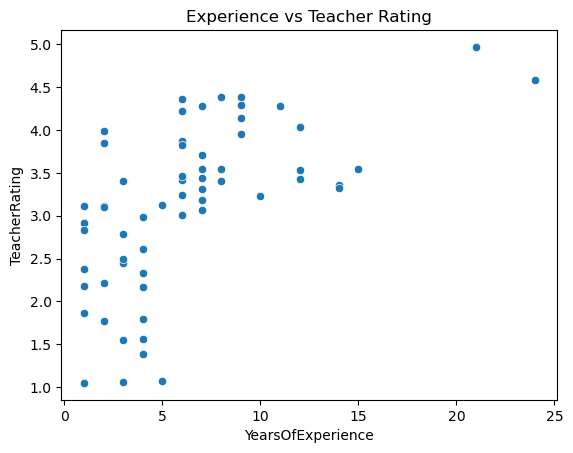

In [24]:
import seaborn as sns

sns.scatterplot(
    data=teachers,
    x='YearsOfExperience',
    y='TeacherRating'
)

plt.title('Experience vs Teacher Rating')
plt.show()






####Does teaching experience translate into better ratings?"

In [25]:
merged = transactions.merge(
    teachers,
    on='TeacherID'
)

merged = merged.merge(
    courses,
    on='CourseID'
)

merged.shape

(10000, 20)

In [28]:
merged.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,TT00001,U00003,CR00016,25/10/2025,0.0,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72
1,TT00002,U00003,CR00037,13/1/2025,0.0,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45
2,TT00003,U00003,CR00019,28/3/2025,0.0,Bank Transfer,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98
3,TT00004,U00004,CR00048,2/6/2025,0.0,Bank Transfer,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64
4,TT00005,U00004,CR00060,10/8/2025,0.0,PayPal,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14


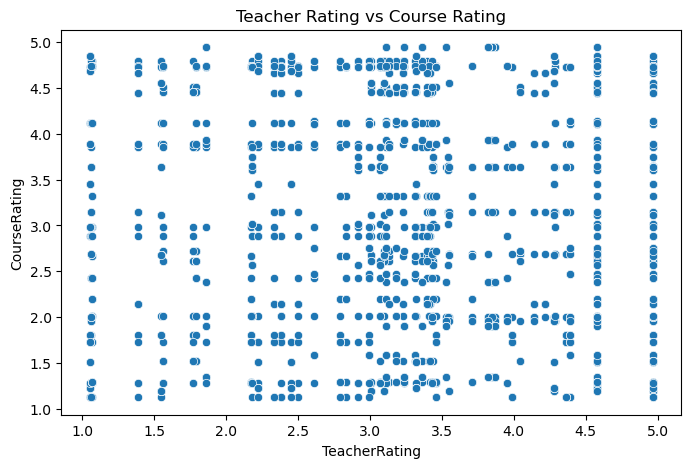

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged,
    x='TeacherRating',
    y='CourseRating'
)

plt.title('Teacher Rating vs Course Rating')
plt.show()




####This visualization evaluates whether highly rated instructors are associated with highly rated courses.

In [30]:

merged[['TeacherRating','CourseRating']].corr()

,TeacherRating,CourseRating
TeacherRating,1.000000,-0.001577
CourseRating,-0.001577,1.000000


In [32]:
category_rating = courses.groupby(
    'CourseCategory'
)['CourseRating'].mean().sort_values(
    ascending=False
)

print(category_rating)

CourseCategory
Marketing                  3.722
Digital Marketing          3.656
Data Science               3.316
Design                     3.162
Project Management         3.142
Artificial Intelligence    3.036
Programming                3.036
Finance                    3.010
Cybersecurity              2.902
Web Development            2.846
Business                   2.688
Machine Learning           2.658
Name: CourseRating, dtype: float64


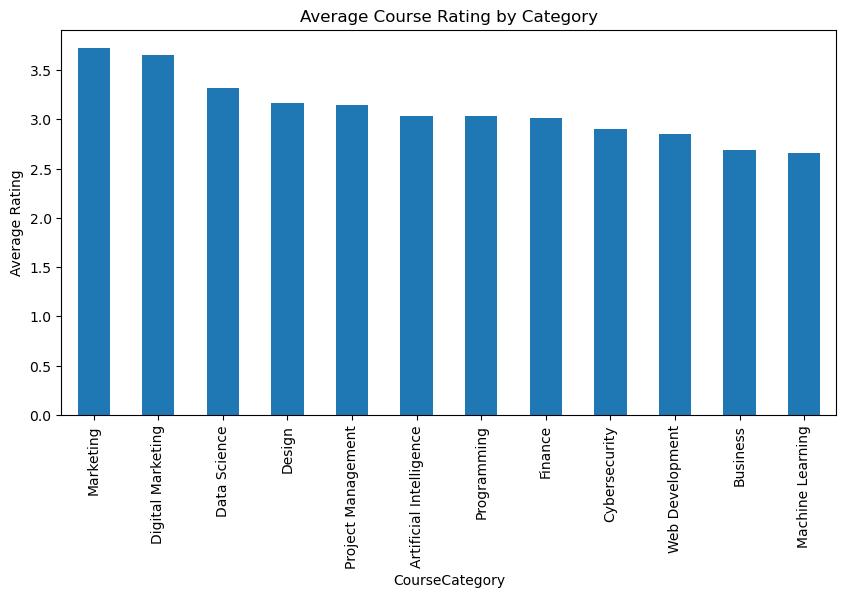

In [37]:
plt.figure(figsize=(10,5))

category_rating.plot(
    kind ='bar'
)

plt.title('Average Course Rating by Category')
plt.ylabel('Average Rating')
plt.show()


###This chart identifies the strongest and weakest performing course categories.

In [39]:
level_rating = courses.groupby(
    'CourseLevel'
)['CourseRating'].mean()

print(level_rating)

CourseLevel
Advanced        2.813810
Beginner        3.189048
Intermediate    3.322778
Name: CourseRating, dtype: float64


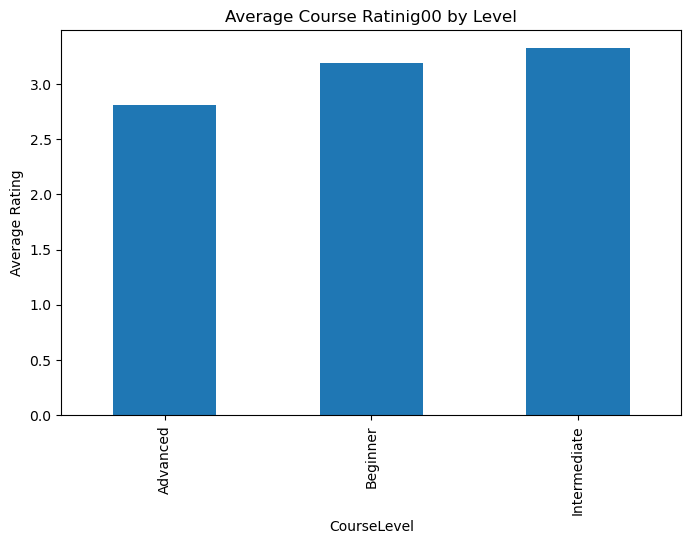

In [41]:
plt.figure(figsize=(8,5))

level_rating.plot(
    kind='bar'
)
plt.title('Average Course Ratinig00 by Level')
plt.ylabel('Average Rating')
plt.show()

###Compare Beginner, Intermediate, and Advanced courses.

In [44]:
expertise_rating = teachers.groupby(
    'Expertise'
)['TeacherRating'].mean().sort_values(
    ascending=False
)

print(expertise_rating)

Expertise
Marketing                  4.290000
Machine Learning           4.234000
Programming                3.950000
Cybersecurity              3.468889
Finance                    3.265000
Artificial Intelligence    3.173333
Digital Marketing          3.050000
Data Science               3.030000
Project Management         2.664000
Web Development            2.514000
Design                     2.290000
Business                   2.245000
Name: TeacherRating, dtype: float64


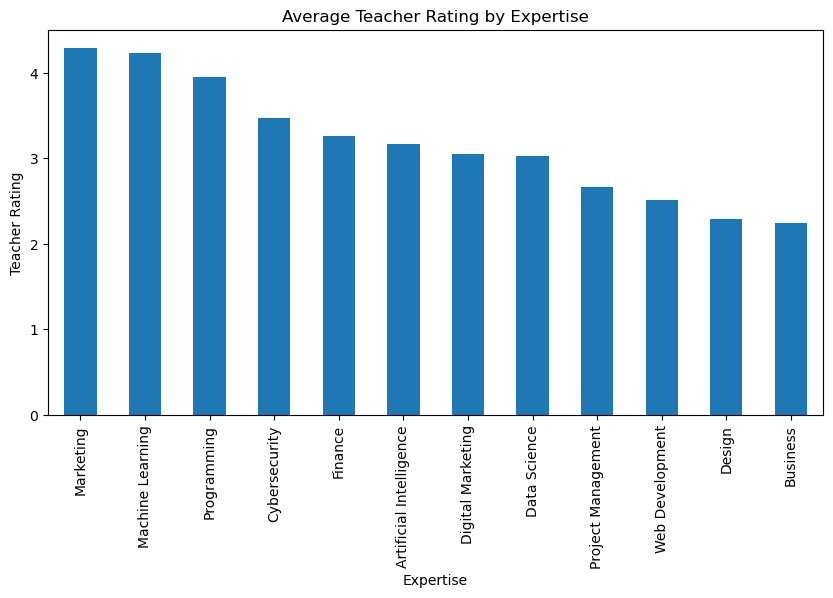

In [45]:
###Identify which expertise domains consistently deliver high-quality instruction.

plt.figure(figsize=(10,5))

expertise_rating.plot(
    kind='bar'
)

plt.title('Average Teacher Rating by Expertise')
plt.ylabel('Teacher Rating')
plt.show()

In [47]:
avg_teacher_rating = teachers['TeacherRating'].mean()
avg_course_rating = courses['CourseRating'].mean()
total_teachers = teachers['TeacherID'].unique()
total_courses = courses['CourseID'].unique()
total_enrollments = len(transactions)

print(avg_teacher_rating)
print(avg_course_rating)
print(total_teachers)
print(total_courses)
print(total_enrollments)

3.1249999999999996
3.097833333333333
['TC00001' 'TC00002' 'TC00003' 'TC00004' 'TC00005' 'TC00006' 'TC00007'
 'TC00008' 'TC00009' 'TC00010' 'TC00011' 'TC00012' 'TC00013' 'TC00014'
 'TC00015' 'TC00016' 'TC00017' 'TC00018' 'TC00019' 'TC00020' 'TC00021'
 'TC00022' 'TC00023' 'TC00024' 'TC00025' 'TC00026' 'TC00027' 'TC00028'
 'TC00029' 'TC00030' 'TC00031' 'TC00032' 'TC00033' 'TC00034' 'TC00035'
 'TC00036' 'TC00037' 'TC00038' 'TC00039' 'TC00040' 'TC00041' 'TC00042'
 'TC00043' 'TC00044' 'TC00045' 'TC00046' 'TC00047' 'TC00048' 'TC00049'
 'TC00050' 'TC00051' 'TC00052' 'TC00053' 'TC00054' 'TC00055' 'TC00056'
 'TC00057' 'TC00058' 'TC00059' 'TC00060']
['CR00001' 'CR00002' 'CR00003' 'CR00004' 'CR00005' 'CR00006' 'CR00007'
 'CR00008' 'CR00009' 'CR00010' 'CR00011' 'CR00012' 'CR00013' 'CR00014'
 'CR00015' 'CR00016' 'CR00017' 'CR00018' 'CR00019' 'CR00020' 'CR00021'
 'CR00022' 'CR00023' 'CR00024' 'CR00025' 'CR00026' 'CR00027' 'CR00028'
 'CR00029' 'CR00030' 'CR00031' 'CR00032' 'CR00033' 'CR00034' 'CR00035

In [48]:
teachers['TeacherID'].unique()

array(['TC00001', 'TC00002', 'TC00003', 'TC00004', 'TC00005', 'TC00006',
       'TC00007', 'TC00008', 'TC00009', 'TC00010', 'TC00011', 'TC00012',
       'TC00013', 'TC00014', 'TC00015', 'TC00016', 'TC00017', 'TC00018',
       'TC00019', 'TC00020', 'TC00021', 'TC00022', 'TC00023', 'TC00024',
       'TC00025', 'TC00026', 'TC00027', 'TC00028', 'TC00029', 'TC00030',
       'TC00031', 'TC00032', 'TC00033', 'TC00034', 'TC00035', 'TC00036',
       'TC00037', 'TC00038', 'TC00039', 'TC00040', 'TC00041', 'TC00042',
       'TC00043', 'TC00044', 'TC00045', 'TC00046', 'TC00047', 'TC00048',
       'TC00049', 'TC00050', 'TC00051', 'TC00052', 'TC00053', 'TC00054',
       'TC00055', 'TC00056', 'TC00057', 'TC00058', 'TC00059', 'TC00060'],
      dtype=object)

In [49]:
total_teachers = teachers['TeacherID'].nunique()
total_courses = courses['CourseID'].nunique()

print(total_teachers)
print(total_courses)

60
60


In [50]:
pip install streamlit pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [51]:
import streamlit as st

2026-06-08 19:01:02.755 
  command:

    streamlit run C:\Users\Harsh Kaushik\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


DeltaGenerator()

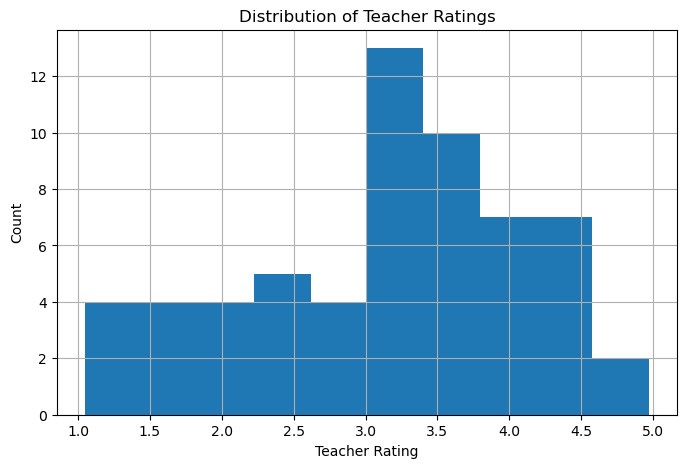

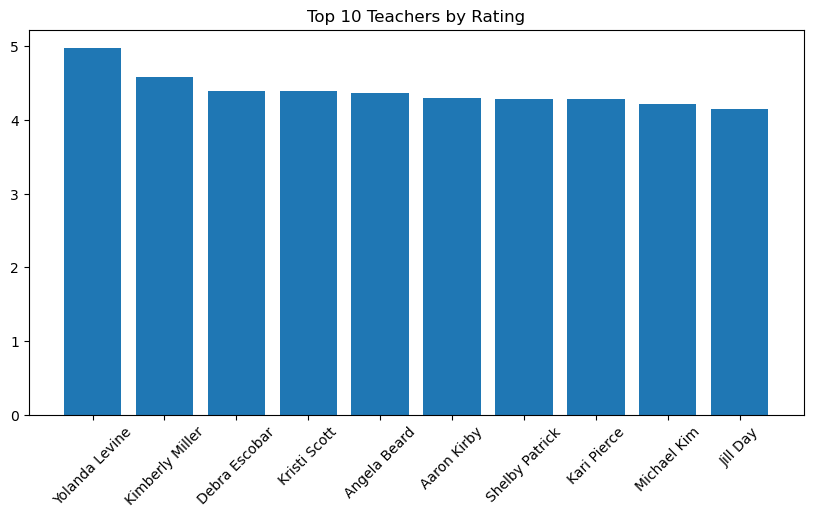

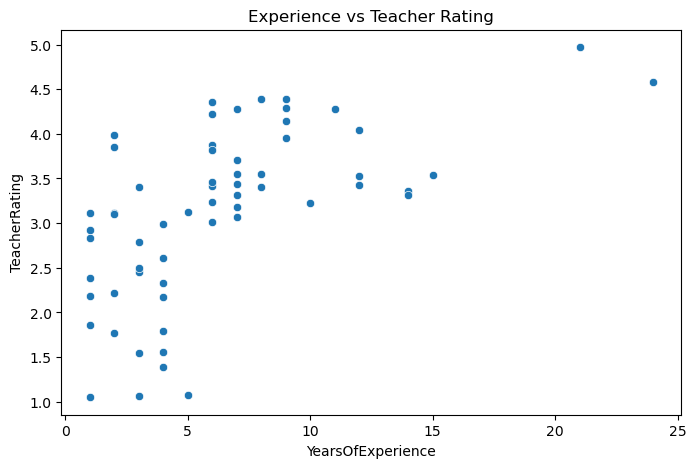

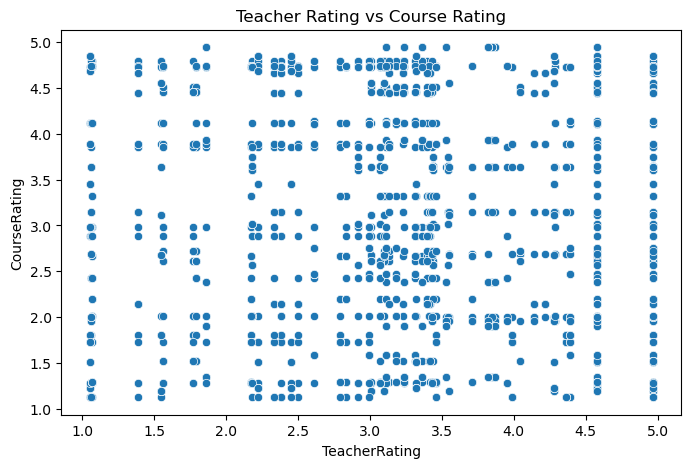

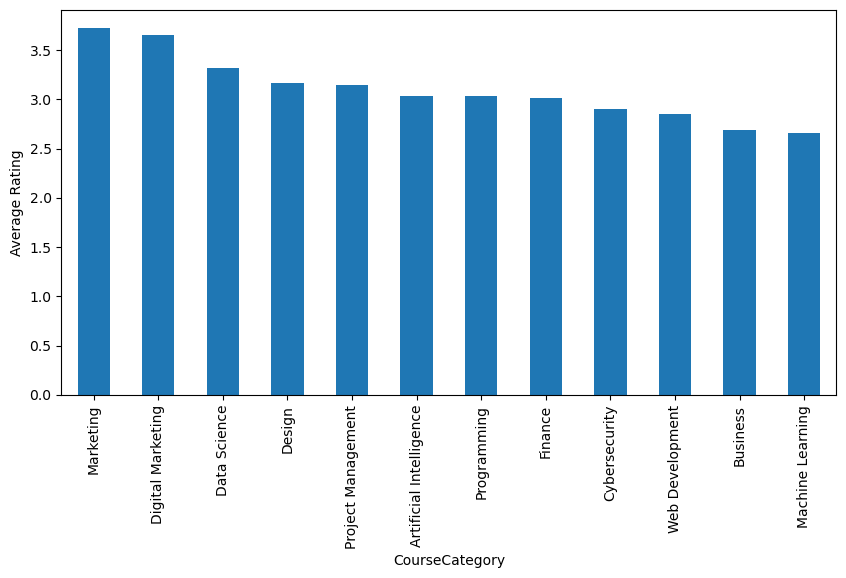

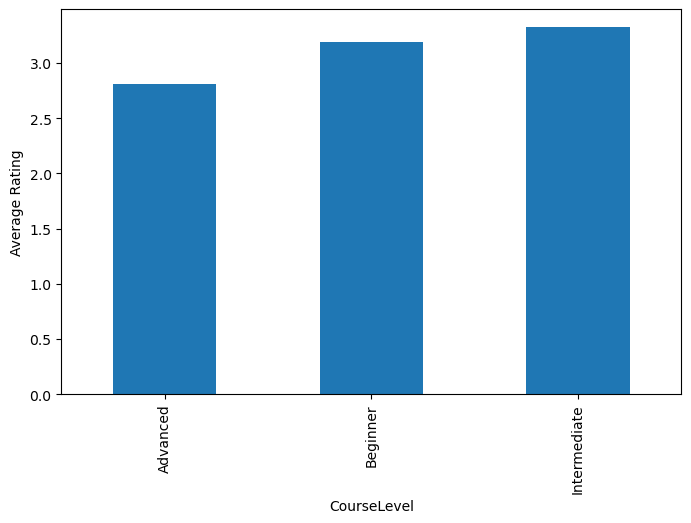

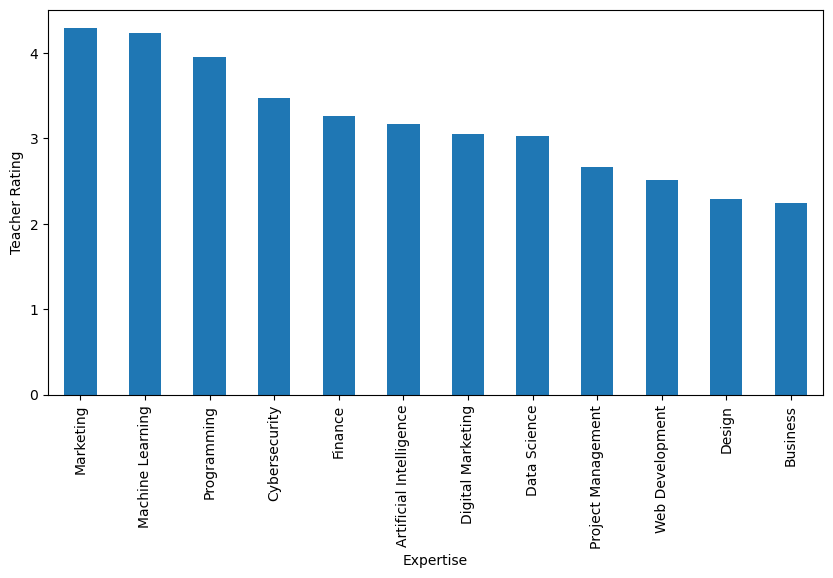

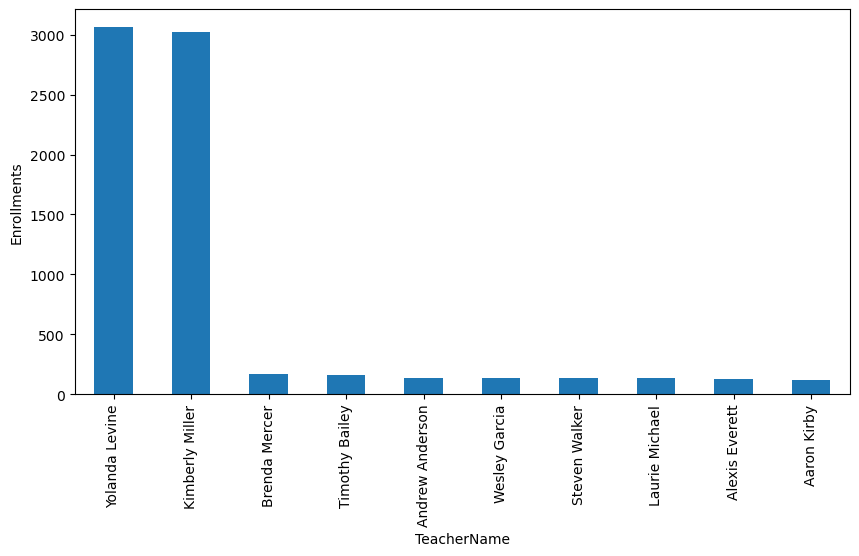

In [52]:
st.set_page_config(
    page_title="EduPro Instructor Analytics",
    layout="wide"
)

st.title("EduPro Instructor & Course Quality Analytics Dashboard")

# Load Data
teachers = pd.read_csv("teacher_data.csv")
courses = pd.read_csv("Course_data1.csv")
transactions = pd.read_csv("transaction_data1.csv")

# Merge Data
merged = transactions.merge(
    teachers,
    on="TeacherID"
).merge(
    courses,
    on="CourseID"
)

# KPIs
avg_teacher_rating = teachers['TeacherRating'].mean()
avg_course_rating = courses['CourseRating'].mean()
total_teachers = teachers['TeacherID'].nunique()
total_courses = courses['CourseID'].nunique()
total_enrollments = len(transactions)

# KPI Section
col1, col2, col3, col4, col5 = st.columns(5)

col1.metric("Teachers", total_teachers)
col2.metric("Courses", total_courses)
col3.metric("Enrollments", total_enrollments)
col4.metric("Avg Teacher Rating", round(avg_teacher_rating,2))
col5.metric("Avg Course Rating", round(avg_course_rating,2))

st.divider()

# Teacher Rating Distribution
st.subheader("Teacher Rating Distribution")

fig, ax = plt.subplots(figsize=(8,5))
teachers['TeacherRating'].hist(bins=10, ax=ax)
ax.set_title("Distribution of Teacher Ratings")
ax.set_xlabel("Teacher Rating")
ax.set_ylabel("Count")
st.pyplot(fig)

# Top Teachers
st.subheader("Top 10 Teachers")

top_teachers = teachers.sort_values(
    by='TeacherRating',
    ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(
    top_teachers['TeacherName'],
    top_teachers['TeacherRating']
)
plt.xticks(rotation=45)
ax.set_title("Top 10 Teachers by Rating")
st.pyplot(fig)

# Experience vs Rating
st.subheader("Experience vs Teacher Rating")

fig, ax = plt.subplots(figsize=(8,5))

sns.scatterplot(
    data=teachers,
    x='YearsOfExperience',
    y='TeacherRating',
    ax=ax
)

ax.set_title("Experience vs Teacher Rating")
st.pyplot(fig)

# Teacher Rating vs Course Rating
st.subheader("Teacher Rating vs Course Rating")

fig, ax = plt.subplots(figsize=(8,5))

sns.scatterplot(
    data=merged,
    x='TeacherRating',
    y='CourseRating',
    ax=ax
)

ax.set_title("Teacher Rating vs Course Rating")
st.pyplot(fig)

# Category Analysis
st.subheader("Course Category Performance")

category_rating = courses.groupby(
    'CourseCategory'
)['CourseRating'].mean().sort_values(
    ascending=False
)

fig, ax = plt.subplots(figsize=(10,5))
category_rating.plot(kind='bar', ax=ax)

ax.set_ylabel("Average Rating")
st.pyplot(fig)

# Course Level Analysis
st.subheader("Course Level Analysis")

level_rating = courses.groupby(
    'CourseLevel'
)['CourseRating'].mean()

fig, ax = plt.subplots(figsize=(8,5))
level_rating.plot(kind='bar', ax=ax)

ax.set_ylabel("Average Rating")
st.pyplot(fig)

# Expertise Analysis
st.subheader("Expertise-wise Performance")

expertise_rating = teachers.groupby(
    'Expertise'
)['TeacherRating'].mean().sort_values(
    ascending=False
)

fig, ax = plt.subplots(figsize=(10,5))
expertise_rating.plot(kind='bar', ax=ax)

ax.set_ylabel("Teacher Rating")
st.pyplot(fig)

# Enrollment Analysis
st.subheader("Top Instructors by Enrollments")

enrollment_by_teacher = merged.groupby(
    'TeacherName'
)['TransactionID'].count().sort_values(
    ascending=False
)

fig, ax = plt.subplots(figsize=(10,5))
enrollment_by_teacher.head(10).plot(
    kind='bar',
    ax=ax
)

ax.set_ylabel("Enrollments")
st.pyplot(fig)

st.success("Dashboard Successfully Loaded")